# SaaS Churn Model Report

This notebook documents the end-to-end churn prediction workflow for the RavenStack synthetic SaaS dataset. It is intended as a portfolio-friendly report: it shows the data, explains the feature table, trains two baseline models, and compares their validation and test performance.

## Project Goal

The goal is to predict whether a SaaS account is likely to churn based on account metadata, subscription history, product usage, and support interactions. The target variable is `churn_flag` from the accounts table.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import (
    load_accounts,
    load_churn_events,
    load_feature_usage,
    load_subscriptions,
    load_support_tickets,
)
from src.evaluation.classification import evaluate_binary_classifier
from src.models import train_baseline_model as tbm

pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")

## Load Raw Tables

The raw dataset is split into five relational CSV files. The feature pipeline aggregates these tables into one account-level training table.

In [2]:
accounts = load_accounts()
subscriptions = load_subscriptions()
feature_usage = load_feature_usage()
support_tickets = load_support_tickets()
churn_events = load_churn_events()

raw_tables = {
    "accounts": accounts,
    "subscriptions": subscriptions,
    "feature_usage": feature_usage,
    "support_tickets": support_tickets,
    "churn_events": churn_events,
}

data_overview = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(frame),
            "columns": frame.shape[1],
            "missing_cells": int(frame.isna().sum().sum()),
        }
        for name, frame in raw_tables.items()
    ]
)
data_overview

,table,rows,columns,missing_cells
0,accounts,500,10,0
1,subscriptions,5000,14,4514
2,feature_usage,25000,8,0
3,support_tickets,2000,9,825
4,churn_events,600,9,148


In [3]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


## Exploratory Analysis

A first sanity check is the target distribution. Class balance matters because churn models often optimize for recall or F1 instead of plain accuracy.

In [4]:
target_distribution = (
    accounts["churn_flag"]
    .value_counts(normalize=True)
    .rename_axis("churn_flag")
    .reset_index(name="share")
)
target_distribution["share_pct"] = (target_distribution["share"] * 100).round(1)
target_distribution

,churn_flag,share,share_pct
0,False,0.78,78.0
1,True,0.22,22.0


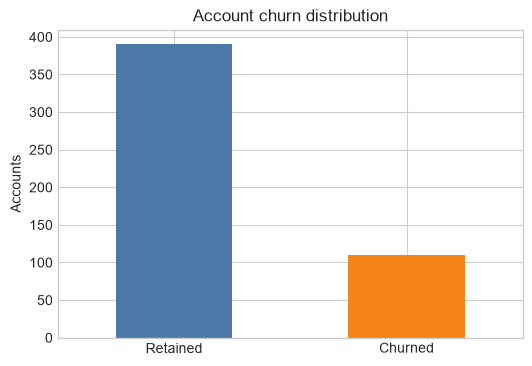

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_data = accounts["churn_flag"].value_counts().sort_index()
plot_data.index = plot_data.index.map({False: "Retained", True: "Churned"})
plot_data.plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"])
ax.set_title("Account churn distribution")
ax.set_xlabel("")
ax.set_ylabel("Accounts")
plt.xticks(rotation=0)
plt.show()

In [6]:
def churn_rate_by(column: str) -> pd.DataFrame:
    return (
        accounts.groupby(column)
        .agg(accounts=("account_id", "count"), churn_rate=("churn_flag", "mean"))
        .sort_values("churn_rate", ascending=False)
        .assign(churn_rate_pct=lambda df: (df["churn_rate"] * 100).round(1))
        .reset_index()
    )

industry_churn = churn_rate_by("industry")
plan_churn = churn_rate_by("plan_tier")

display(industry_churn)
display(plan_churn)

,industry,accounts,churn_rate,churn_rate_pct
0,DevTools,113,0.309735,31.0
1,FinTech,112,0.223214,22.3
2,HealthTech,96,0.218750,21.9
3,EdTech,79,0.164557,16.5
4,Cybersecurity,100,0.160000,16.0


,plan_tier,accounts,churn_rate,churn_rate_pct
0,Enterprise,154,0.220779,22.1
1,Basic,168,0.220238,22.0
2,Pro,178,0.219101,21.9


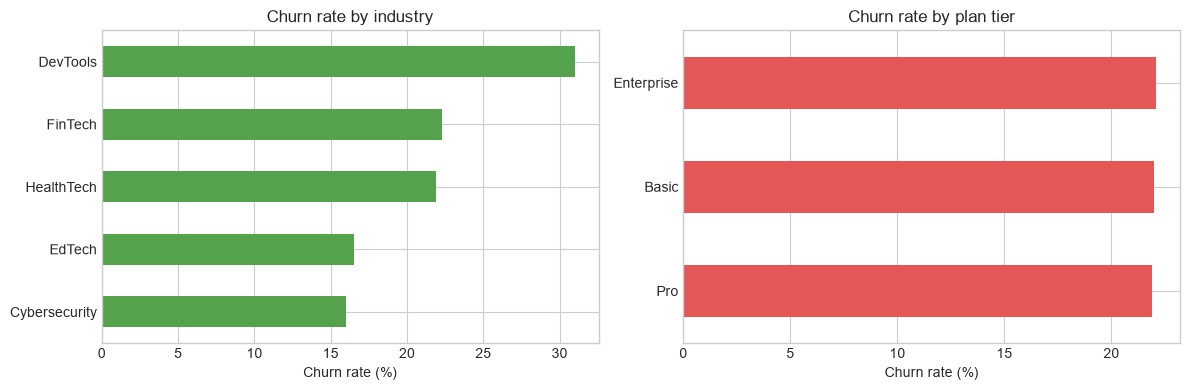

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

industry_churn.sort_values("churn_rate_pct").plot(
    x="industry",
    y="churn_rate_pct",
    kind="barh",
    ax=axes[0],
    legend=False,
    color="#54a24b",
)
axes[0].set_title("Churn rate by industry")
axes[0].set_xlabel("Churn rate (%)")
axes[0].set_ylabel("")

plan_churn.sort_values("churn_rate_pct").plot(
    x="plan_tier",
    y="churn_rate_pct",
    kind="barh",
    ax=axes[1],
    legend=False,
    color="#e45756",
)
axes[1].set_title("Churn rate by plan tier")
axes[1].set_xlabel("Churn rate (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Feature Engineering

The project builds a single account-level feature table. For churned accounts, the snapshot date is set before the churn date, so usage and support activity after churn do not leak into the model.

In [8]:
features = tbm.load_training_data()

print(f"Feature table shape: {features.shape[0]} rows x {features.shape[1]} columns")
features.head()

Feature table shape: 500 rows x 53 columns


,account_id,account_name,industry,country,referral_source,plan_tier,seats,is_trial,churn_flag,account_age_days,avg_mrr,max_mrr,avg_arr,max_arr,total_arr,avg_seats,max_seats,subscription_count,has_upgrade,has_downgrade,auto_renew_rate,trial_rate,monthly_billing_rate,annual_billing_rate,total_usage_count,avg_usage_count,total_usage_duration_secs,avg_usage_duration_secs,unique_features_used,total_error_count,avg_error_count,beta_feature_rate,usage_event_count,has_usage,ticket_count,urgent_ticket_rate,high_priority_ticket_rate,medium_priority_ticket_rate,low_priority_ticket_rate,avg_resolution_hours,max_resolution_hours,avg_first_response_minutes,avg_satisfaction_score,min_satisfaction_score,escalation_rate,has_escalation,tickets_per_month,usage_per_day,error_rate,account_activity_score,errors_per_day,tickets_per_usage,tickets_per_feature
0,A-2e4581,Company_0,EdTech,US,partner,Basic,9,False,False,76,1260.300000,5771.0,15123.6,69252.0,151236.0,31.200000,102.0,10.0,True,False,0.800000,0.200000,0.700000,0.300000,535.0,9.727273,152339.0,2769.800000,27.0,38.0,0.690909,0.072727,55.0,True,2.0,0.500000,0.500000,0.000000,0.0,23.000000,27.0,91.000000,3.000000,3.0,0.000000,False,0.789474,7.039474,0.071028,190.065789,0.500000,0.003738,0.074074
1,A-43a9e3,Company_1,FinTech,IN,other,Basic,18,False,True,502,1250.500000,5572.0,15006.0,66864.0,120048.0,22.000000,28.0,8.0,True,False,0.750000,0.000000,0.250000,0.750000,355.0,10.142857,101136.0,2889.600000,23.0,14.0,0.400000,0.057143,35.0,True,3.0,0.666667,0.000000,0.333333,0.0,38.000000,64.0,73.333333,4.000000,3.0,0.000000,False,0.179283,0.707171,0.039437,16.264940,0.027888,0.008451,0.130435
2,A-0a282f,Company_2,DevTools,US,organic,Basic,1,False,False,126,1219.066667,5771.0,14628.8,69252.0,219432.0,18.800000,60.0,15.0,True,True,1.000000,0.066667,0.533333,0.466667,821.0,9.891566,251210.0,3026.626506,34.0,48.0,0.578313,0.060241,83.0,True,3.0,0.333333,0.000000,0.666667,0.0,43.666667,65.0,63.666667,4.666667,4.0,0.000000,False,0.714286,6.515873,0.058465,221.539683,0.380952,0.003654,0.088235
3,A-1f0ac7,Company_3,HealthTech,UK,other,Basic,24,True,False,492,1325.000000,4776.0,15900.0,57312.0,111300.0,29.857143,47.0,7.0,True,False,0.714286,0.142857,0.571429,0.428571,382.0,9.317073,102528.0,2500.682927,26.0,21.0,0.512195,0.121951,41.0,True,2.0,0.000000,0.500000,0.000000,0.5,29.000000,44.0,174.000000,NaN,NaN,0.000000,False,0.121951,0.776423,0.054974,20.186992,0.042683,0.005236,0.076923
4,A-ce550d,Company_4,HealthTech,US,event,Enterprise,35,False,True,61,3383.750000,10746.0,40605.0,128952.0,324840.0,39.375000,54.0,8.0,True,False,0.625000,0.125000,0.375000,0.625000,462.0,9.428571,168859.0,3446.102041,29.0,24.0,0.489796,0.040816,49.0,True,7.0,0.285714,0.285714,0.428571,0.0,42.285714,69.0,107.857143,3.800000,3.0,0.142857,True,3.442623,7.573770,0.051948,219.639344,0.393443,0.015152,0.241379


In [9]:
numeric_summary = (
    features.select_dtypes(include="number")
    .drop(columns=["churn_flag"], errors="ignore")
    .describe()
    .T
    .sort_values("std", ascending=False)
)

numeric_summary.head(12)

,count,mean,std,min,25%,50%,75%,max
total_arr,488.0,252103.008197,211938.344234,0.000000,116964.000000,207138.000000,333783.000000,1656720.0
total_usage_duration_secs,500.0,132515.688000,64960.093050,0.000000,90083.250000,138053.500000,177937.000000,281986.0
max_arr,488.0,87868.991803,61082.644661,0.000000,42984.000000,75222.000000,117012.000000,405960.0
avg_arr,488.0,27690.862853,21544.508294,0.000000,14676.800000,22713.857143,33923.228571,165672.0
max_mrr,488.0,7322.415984,5090.220388,0.000000,3582.000000,6268.500000,9751.000000,33830.0
avg_mrr,488.0,2307.571904,1795.375691,0.000000,1223.066667,1892.821429,2826.935714,13806.0
account_activity_score,500.0,140.805419,871.393176,0.000000,18.811524,39.322340,96.244125,18624.0
avg_usage_duration_secs,488.0,3046.302493,436.446493,1543.266667,2825.469640,3027.763273,3240.169565,7973.0
total_usage_count,500.0,436.954000,213.334778,0.000000,295.750000,452.000000,598.250000,1005.0
account_age_days,500.0,296.924000,212.035687,0.000000,105.500000,261.000000,469.000000,729.0


## Modeling

The notebook uses the same preprocessing and model builders as the Python pipeline. This keeps the report aligned with the code under `src/` instead of duplicating separate notebook-only logic.

In [10]:
X, y = tbm.split_features_and_target(features)
X_train, X_val, X_test, y_train, y_val, y_test = tbm.split_train_validation_test(X, y)

split_overview = pd.DataFrame(
    [
        {"split": "train", "rows": len(X_train), "churn_rate": y_train.mean()},
        {"split": "validation", "rows": len(X_val), "churn_rate": y_val.mean()},
        {"split": "test", "rows": len(X_test), "churn_rate": y_test.mean()},
    ]
)
split_overview["churn_rate_pct"] = (split_overview["churn_rate"] * 100).round(1)
split_overview

,split,rows,churn_rate,churn_rate_pct
0,train,300,0.22,22.0
1,validation,100,0.22,22.0
2,test,100,0.22,22.0


In [11]:
def compact_metrics(model_name: str, split: str, metrics: dict[str, object]) -> dict[str, float | str]:
    return {
        "model": model_name,
        "split": split,
        "threshold": metrics["threshold"],
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "average_precision": metrics["average_precision"],
    }

models = {
    "Logistic Regression": tbm.build_logistic_regression_model(X_train),
    "Random Forest": tbm.build_random_forest_model(X_train),
}

fitted_models = {}
metric_rows = []
confusion_matrices = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    validation_metrics = evaluate_binary_classifier(
        model=model,
        X_test=X_val,
        y_test=y_val,
        model_name=f"{model_name} validation",
        threshold=tbm.FIXED_THRESHOLD,
    )
    metric_rows.append(compact_metrics(model_name, "validation", validation_metrics))

    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)
    model.fit(X_train_full, y_train_full)

    test_metrics = evaluate_binary_classifier(
        model=model,
        X_test=X_test,
        y_test=y_test,
        model_name=f"{model_name} test",
        threshold=tbm.FIXED_THRESHOLD,
    )
    metric_rows.append(compact_metrics(model_name, "test", test_metrics))
    confusion_matrices[(model_name, "test")] = test_metrics["confusion_matrix"]
    fitted_models[model_name] = model

metrics_df = pd.DataFrame(metric_rows)
metrics_df

Logistic Regression validation
Threshold: 0.42
Accuracy:  0.740
Precision: 0.438
Recall:    0.636
F1:        0.519
ROC AUC:   0.734
PR AUC:    0.541

Confusion Matrix:
[[60 18]
 [ 8 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82        78
           1       0.44      0.64      0.52        22

    accuracy                           0.74       100
   macro avg       0.66      0.70      0.67       100
weighted avg       0.78      0.74      0.76       100

Logistic Regression test
Threshold: 0.42
Accuracy:  0.720
Precision: 0.425
Recall:    0.773
F1:        0.548
ROC AUC:   0.825
PR AUC:    0.713

Confusion Matrix:
[[55 23]
 [ 5 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80        78
           1       0.42      0.77      0.55        22

    accuracy                           0.72       100
   macro avg       0.67      0.74      

,model,split,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,validation,0.42,0.74,0.437500,0.636364,0.518519,0.733683,0.540505
1,Logistic Regression,test,0.42,0.72,0.425000,0.772727,0.548387,0.824592,0.712722
2,Random Forest,validation,0.42,0.83,0.777778,0.318182,0.451613,0.706876,0.591738
3,Random Forest,test,0.42,0.89,0.789474,0.681818,0.731707,0.804196,0.714805


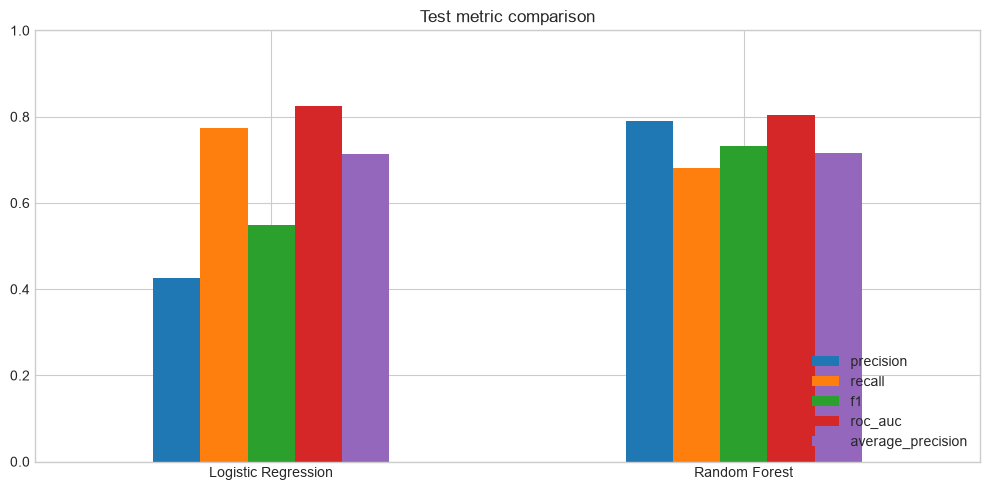

In [12]:
test_metrics_df = metrics_df[metrics_df["split"] == "test"].set_index("model")
score_columns = ["precision", "recall", "f1", "roc_auc", "average_precision"]

ax = test_metrics_df[score_columns].plot(kind="bar", figsize=(10, 5))
ax.set_title("Test metric comparison")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\knock\AppData\Local\Temp\ipykernel_12996\22443814.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


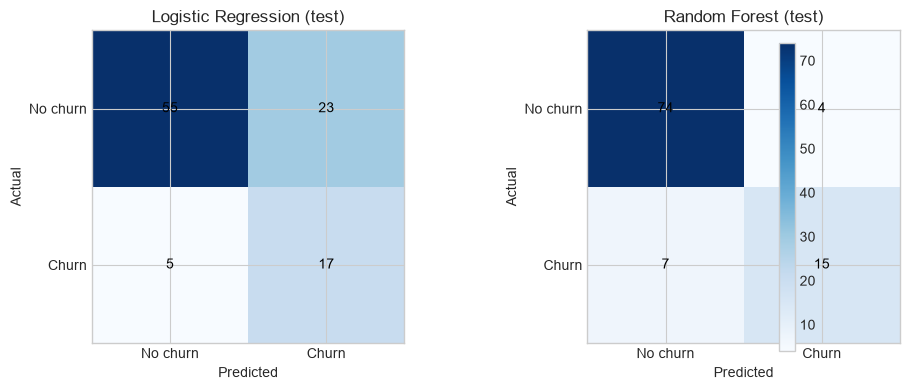

In [13]:
fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(10, 4))
if len(confusion_matrices) == 1:
    axes = [axes]

for ax, ((model_name, split), matrix) in zip(axes, confusion_matrices.items()):
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(f"{model_name} ({split})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], labels=["No churn", "Churn"])
    ax.set_yticks([0, 1], labels=["No churn", "Churn"])
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, matrix[row, col], ha="center", va="center", color="black")

fig.colorbar(image, ax=axes, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Model Interpretation

Random Forest feature importance is a practical first look at which engineered signals the model uses most. These values are model-specific and should be interpreted as directional, not causal.

In [14]:
random_forest = fitted_models["Random Forest"]
feature_names = random_forest.named_steps["preprocessor"].get_feature_names_out()
feature_importances = random_forest.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": feature_importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

importance_df

,feature,importance
16,numeric__total_usage_duration_secs,0.086487
14,numeric__total_usage_count,0.078229
18,numeric__unique_features_used,0.076892
22,numeric__usage_event_count,0.071770
19,numeric__total_error_count,0.066159
9,numeric__subscription_count,0.037490
39,numeric__tickets_per_usage,0.028544
1,numeric__account_age_days,0.027052
37,numeric__account_activity_score,0.025240
21,numeric__beta_feature_rate,0.024633


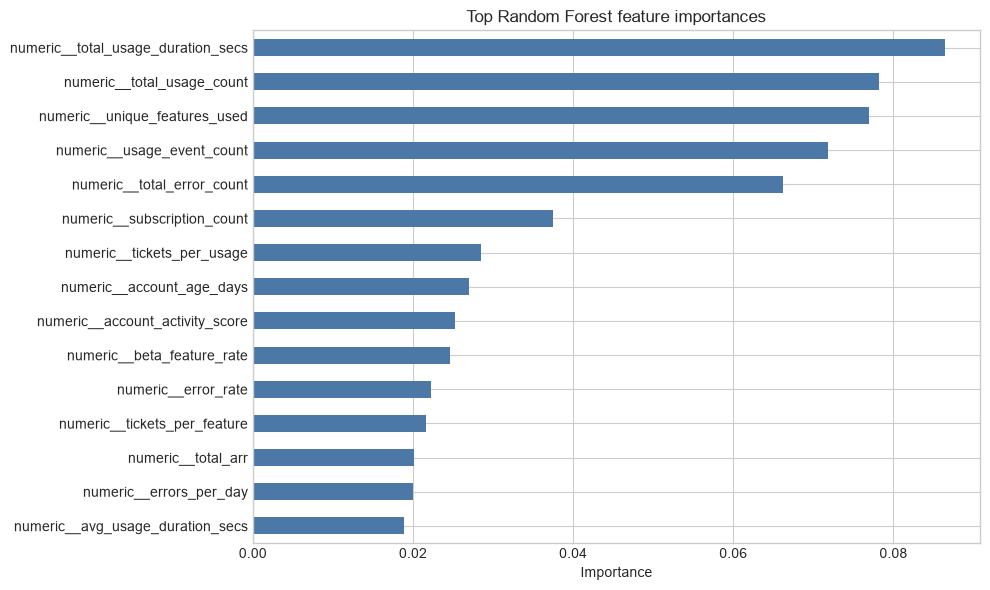

In [15]:
ax = importance_df.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 6),
    legend=False,
    color="#4c78a8",
)
ax.set_title("Top Random Forest feature importances")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Conclusion

This report demonstrates a complete baseline churn workflow: loading relational SaaS data, aggregating account-level features without using post-churn activity, training two supervised classifiers, and comparing them with threshold-based metrics.

Recommended next steps:

1. Align the fixed threshold with the tests and saved model artifacts.
2. Add targeted unit tests for snapshot-date feature engineering.
3. Add the best model metrics and a screenshot from this notebook to the README.
4. Build a small Streamlit dashboard only after the notebook and reproducibility check are stable.